# 03: Comparison-City Demographics: Does Gotham's Pattern Generalize?

This notebook checks whether there are consistent demographic shifts across the 4 comparison-city relocations.

**Inputs:** `data/processed/{kansas_city,san_diego,seattle_tacoma,dc}_tract_travel_times.csv`,
`data/raw/census/acs_demographics_comparison_cities.csv`,
`output/gotham_reachable_demographics.csv` (Gotham's numbers, already computed)
**Outputs:** `output/comparison_cities_reachable_demographics.csv`,
`output/demographic_shift_comparison.png`


In [2]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from plot_theme import set_mpl_theme
set_mpl_theme()

DATA_PROCESSED_DIR = os.path.join("..", "data", "processed")
DATA_CENSUS_DIR = os.path.join("..", "data", "raw", "census")
OUTPUT_DIR = os.path.join("..", "output")

demo = pd.read_csv(os.path.join(DATA_CENSUS_DIR, "acs_demographics_comparison_cities.csv"), dtype={"GEOID": str})
demo["GEOID"] = demo["GEOID"].str.zfill(11)
demo.head()


,NAME,population,median_household_income,median_age,white_nh,black_nh,asian_nh,hispanic_latino,state,county,tract,GEOID
0,Census Tract 9501; Adair County; Missouri,3817,71250.0,41.2,3546,2,15,164,29,1,950100,29001950100
1,Census Tract 9502; Adair County; Missouri,2843,66964.0,46.8,2700,5,10,59,29,1,950200,29001950200
2,Census Tract 9503; Adair County; Missouri,3280,31341.0,32.9,3079,7,54,65,29,1,950300,29001950300
3,Census Tract 9504; Adair County; Missouri,4139,55500.0,33.1,3740,124,82,77,29,1,950400,29001950400
4,Census Tract 9505.01; Adair County; Missouri,3688,70147.0,33.5,2687,637,78,123,29,1,950501,29001950501


## Reachable-population demographics per relocation

Join tract travel times to ACS demographics, filter to the 60-min reachable set, compute race/ethnicity counts and population-weighted income/age for old vs. new stadium.


In [3]:
METRO_TEAMS = {
    "kansas_city": "Kansas City Current",
    "san_diego": "San Diego Wave FC",
    "seattle_tacoma": "Seattle Reign FC",
    "dc": "Washington Spirit",
}
RACE_COLS = ["white_nh", "black_nh", "asian_nh", "hispanic_latino"]

demo_rows = []
for metro_key, team in METRO_TEAMS.items():
    tt = pd.read_csv(os.path.join(DATA_PROCESSED_DIR, f"{metro_key}_tract_travel_times.csv"), dtype={"GEOID": str})
    tt["GEOID"] = tt["GEOID"].str.zfill(11)
    tt = tt.merge(demo, on="GEOID", how="left")
    for site_label in ["old", "new"]:
        reachable = tt[(tt["site_label"] == site_label) & (tt["travel_time_minutes"] <= 60)]
        total_pop = reachable["population"].sum()
        row = {"team": team, "site_label": site_label, "reachable_population": total_pop}
        for race_col in RACE_COLS:
            row[f"{race_col}_count"] = reachable[race_col].sum()
            row[f"pct_{race_col}"] = (reachable[race_col].sum() / total_pop * 100) if total_pop else np.nan
        for stat_col in ["median_household_income", "median_age"]:
            weights = reachable["population"]
            vals = reachable[stat_col]
            mask = vals.notna() & weights.notna()
            row[f"weighted_{stat_col}"] = np.average(vals[mask], weights=weights[mask]) if mask.any() else np.nan
        demo_rows.append(row)

comparison_demo_df = pd.DataFrame(demo_rows)
comparison_demo_df.to_csv(os.path.join(OUTPUT_DIR, "comparison_cities_reachable_demographics.csv"), index=False)
comparison_demo_df


,team,site_label,reachable_population,white_nh_count,pct_white_nh,black_nh_count,pct_black_nh,asian_nh_count,pct_asian_nh,hispanic_latino_count,pct_hispanic_latino,weighted_median_household_income,weighted_median_age
0,Kansas City Current,old,6028,3381,56.088255,1387,23.009290,288,4.777704,382,6.337094,99939.452555,37.441855
1,Kansas City Current,new,123809,59724,48.238819,32612,26.340573,4236,3.421399,19877,16.054568,56442.622549,34.349752
2,San Diego Wave FC,old,358541,190964,53.261412,15162,4.228805,47209,13.166974,80446,22.437043,100183.461704,36.128448
3,San Diego Wave FC,new,402583,194915,48.416103,26988,6.703711,43186,10.727229,110976,27.565993,90713.022172,35.065475
4,Seattle Reign FC,old,77359,47837,61.837666,8575,11.084683,3835,4.957406,8321,10.756344,80275.343890,38.157436
5,Seattle Reign FC,new,833559,461169,55.325298,58368,7.002264,168909,20.263593,76812,9.214945,128284.846557,36.576830
6,Washington Spirit,old,25934,6848,26.405491,5764,22.225650,8084,31.171435,3882,14.968767,151979.576078,41.534152
7,Washington Spirit,new,676306,212638,31.441093,313817,46.401629,26689,3.946291,89491,13.232324,107870.448849,35.797277


## Does Gotham's shift generalize?

For each relocation (Gotham included), compute the change in white-non-Hispanic share and
median household income, old venue to new. If the other 4 relocations show the same direction
of shift, that's evidence this is a general consequence of moving toward accessibility, not
something specific to Gotham's particular geography.


In [4]:
gotham_demo = pd.read_csv(os.path.join(OUTPUT_DIR, "gotham_reachable_demographics.csv"))
gotham_demo = gotham_demo.rename(columns={"site_label": "site_label_gotham"})
gotham_demo["site_label"] = gotham_demo["site_label_gotham"].map({"current": "old", "future": "new"})
gotham_demo["team"] = "NJ/NY Gotham FC (Sports Illustrated Stadium -> Etihad Park)"

all_teams_demo = pd.concat([
    comparison_demo_df,
    gotham_demo[["team", "site_label", "reachable_population", "pct_white_nh",
                 "weighted_median_household_income", "weighted_median_age"]],
], ignore_index=True)

shift_rows = []
for team in all_teams_demo["team"].unique():
    sub = all_teams_demo[all_teams_demo["team"] == team]
    old_row = sub[sub["site_label"] == "old"]
    new_row = sub[sub["site_label"] == "new"]
    if old_row.empty or new_row.empty:
        continue
    shift_rows.append({
        "team": team,
        "white_share_change_pp": new_row["pct_white_nh"].iloc[0] - old_row["pct_white_nh"].iloc[0],
        "income_change_pct": (new_row["weighted_median_household_income"].iloc[0]
                               / old_row["weighted_median_household_income"].iloc[0] - 1) * 100,
    })
shift_df = pd.DataFrame(shift_rows)
shift_df


,team,white_share_change_pp,income_change_pct
0,Kansas City Current,-7.849435,-43.523182
1,San Diego Wave FC,-4.845309,-9.453097
2,Seattle Reign FC,-6.512368,59.806038
3,Washington Spirit,5.035602,-29.023062
4,NJ/NY Gotham FC (Sports Illustrated Stadium -> Etihad Park),14.099912,18.577700


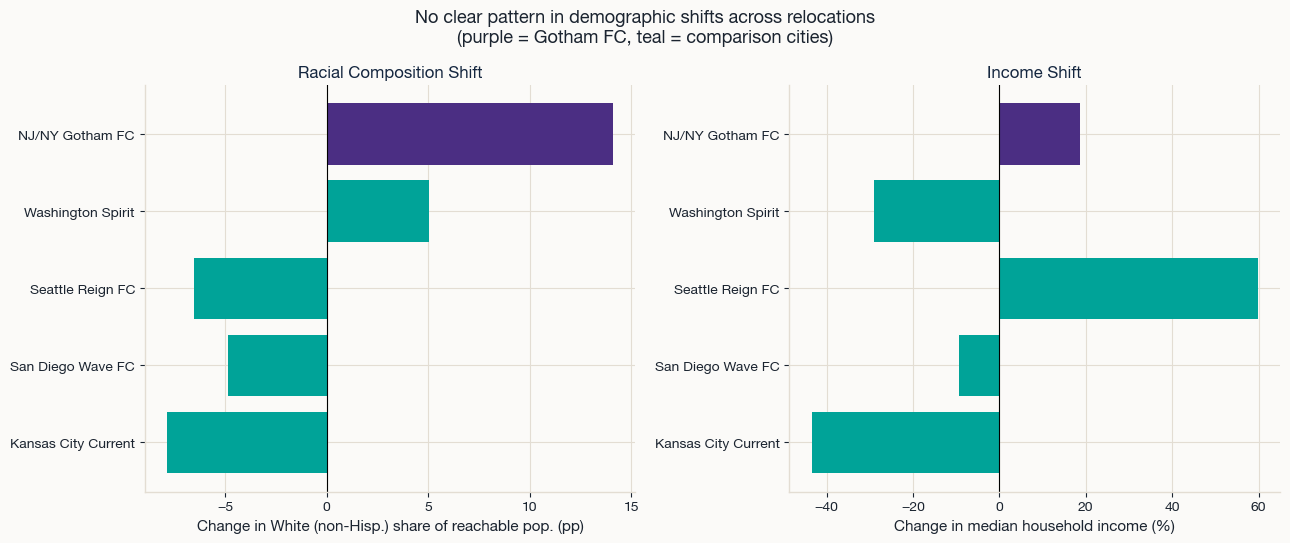

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

colors = ["#4B2E83" if "Gotham" in t else "#00A398" for t in shift_df["team"]]
short_names = [t.split(" (")[0] for t in shift_df["team"]]

ax1.barh(short_names, shift_df["white_share_change_pp"], color=colors)
ax1.axvline(0, color="black", linewidth=0.8)
ax1.set_xlabel("Change in White (non-Hisp.) share of reachable pop. (pp)")
ax1.set_title("Racial Composition Shift", fontsize=12, fontweight="bold")

ax2.barh(short_names, shift_df["income_change_pct"], color=colors)
ax2.axvline(0, color="black", linewidth=0.8)
ax2.set_xlabel("Change in median household income (%)")
ax2.set_title("Income Shift", fontsize=12, fontweight="bold")

fig.suptitle("No clear pattern in demographic shifts across relocations\n(purple = Gotham FC, teal = comparison cities)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "demographic_shift_comparison.png"), dpi=160, facecolor="white")
plt.show()


## Interpretation

It doesn't generalize, so not worth deeper exploration at this time. This change is explainable by the inclusion of Manhattan within the isochrone range.
